In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Display settings
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")
%matplotlib inline


df = pd.read_csv("data/insurance.csv")


print("Shape:", df.shape)
df.head()

Shape: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [2]:
print("--- Info ---")
df.info()

print("\n--- Missing Values ---")
print(df.isnull().sum())

print("\n--- Duplicates ---")
print("Duplicate rows:", df.duplicated().sum())

--- Info ---
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB

--- Missing Values ---
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

--- Duplicates ---
Duplicate rows: 1


In [3]:
# Numeric summary
num_cols = df.select_dtypes(include=np.number).columns.tolist()
print("Numeric columns:", num_cols)

summary = pd.DataFrame({
    "mean":     df[num_cols].mean(),
    "median":   df[num_cols].median(),
    "std":      df[num_cols].std(),
    "IQR":      df[num_cols].quantile(0.75) - df[num_cols].quantile(0.25),
    "skewness": df[num_cols].skew(),
    "kurtosis": df[num_cols].kurtosis()
})
summary.round(2)

Numeric columns: ['age', 'bmi', 'children', 'charges']


,mean,median,std,IQR,skewness,kurtosis
age,39.21,39.00,14.05,24.00,0.06,-1.25
bmi,30.66,30.40,6.10,8.40,0.28,-0.05
children,1.09,1.00,1.21,2.00,0.94,0.20
charges,13270.42,9382.03,12110.01,11899.63,1.52,1.61


In [4]:
cat_cols = df.select_dtypes(include="object").columns.tolist()
print("Categorical columns:", cat_cols)

for col in cat_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())

Categorical columns: ['sex', 'smoker', 'region']

--- sex ---
sex
male      676
female    662
Name: count, dtype: int64

--- smoker ---
smoker
no     1064
yes     274
Name: count, dtype: int64

--- region ---
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64


C:\Users\Administrator\AppData\Local\Temp\ipykernel_3832\1045783244.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include="object").columns.tolist()


In [5]:
# Drop duplicate rows
df = df.drop_duplicates().reset_index(drop=True)
print("New shape:", df.shape)

# Fix the pandas warning for future select_dtypes calls
cat_cols = df.select_dtypes(include="str").columns.tolist()
num_cols = df.select_dtypes(include=np.number).columns.tolist()
print("Categorical:", cat_cols)
print("Numeric:", num_cols)

New shape: (1337, 7)
Categorical: ['sex', 'smoker', 'region']
Numeric: ['age', 'bmi', 'children', 'charges']


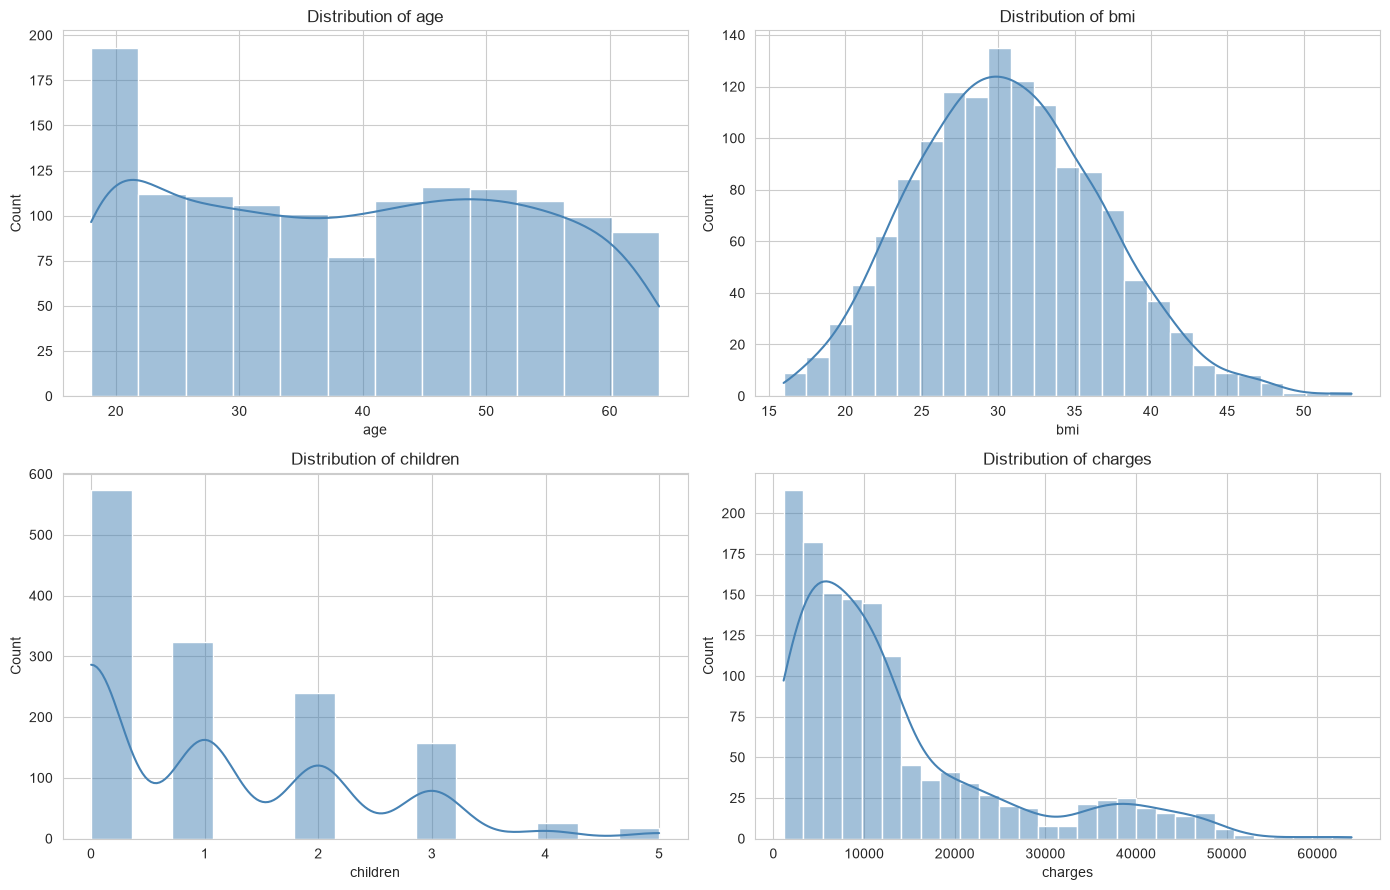

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color="steelblue")
    axes[i].set_title(f"Distribution of {col}", fontsize=12)
    axes[i].set_xlabel(col)

plt.tight_layout()
plt.show()

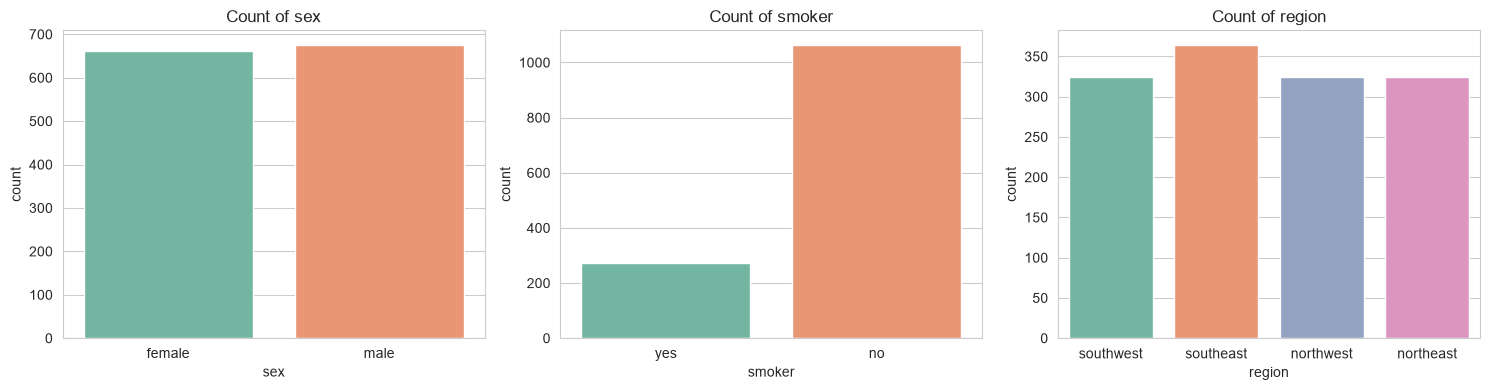

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(cat_cols):
    sns.countplot(data=df, x=col, ax=axes[i], palette="Set2", hue=col, legend=False)
    axes[i].set_title(f"Count of {col}")

plt.tight_layout()
plt.show()

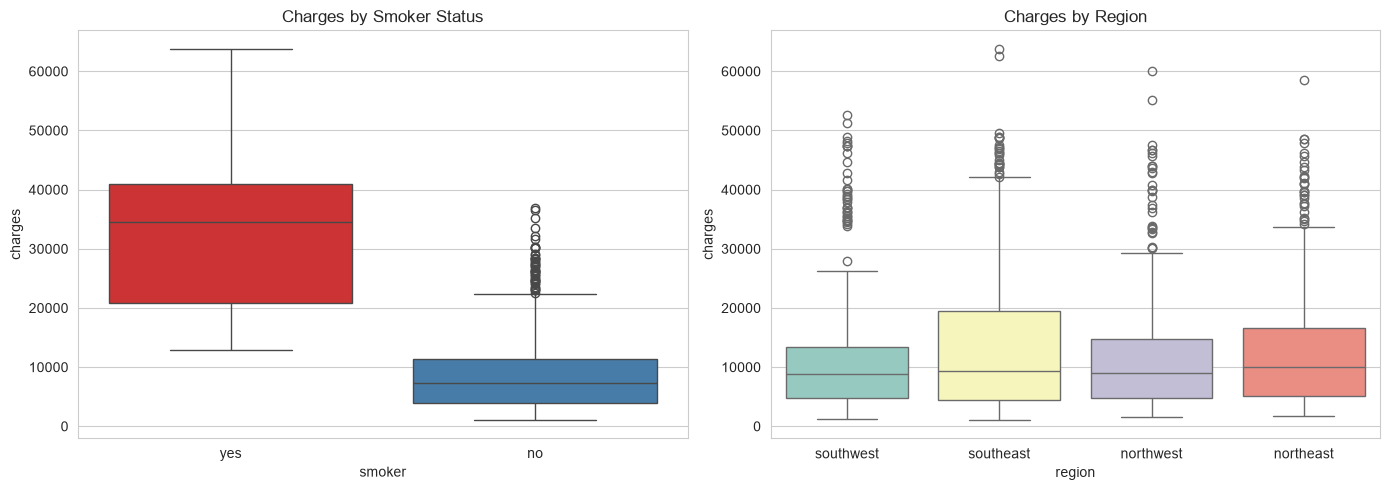

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x="smoker", y="charges", ax=axes[0], palette="Set1", hue="smoker", legend=False)
axes[0].set_title("Charges by Smoker Status")

sns.boxplot(data=df, x="region", y="charges", ax=axes[1], palette="Set3", hue="region", legend=False)
axes[1].set_title("Charges by Region")

plt.tight_layout()
plt.show()

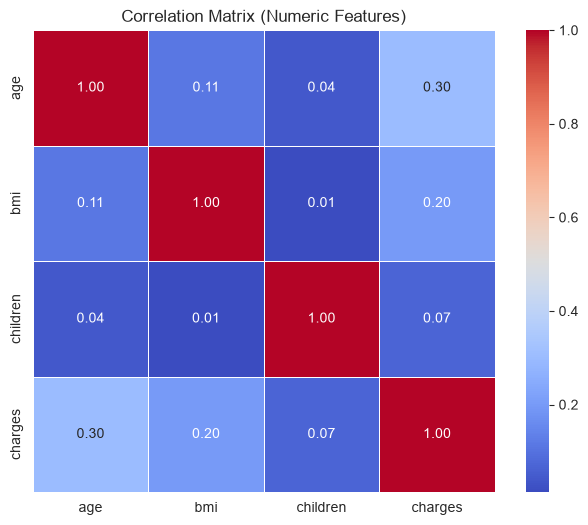

In [10]:
plt.figure(figsize=(8, 6))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", square=True, linewidths=0.5)
plt.title("Correlation Matrix (Numeric Features)")
plt.show()

In [11]:
# --- Hypothesis Test 1: Smokers vs Non-Smokers on Charges ---

# H0: There is NO difference in mean charges between smokers and non-smokers (μ_smoker = μ_nonsmoker)
# H1: There IS a significant difference in mean charges between smokers and non-smokers (μ_smoker ≠ μ_nonsmoker)
# Alpha = 0.05 (two-tailed)

# Split the two groups
smokers    = df[df["smoker"] == "yes"]["charges"]
nonsmokers = df[df["smoker"] == "no"]["charges"]

print(f"Smokers    : n = {len(smokers)},    mean = {smokers.mean():.2f}, median = {smokers.median():.2f}")
print(f"Non-smokers: n = {len(nonsmokers)}, mean = {nonsmokers.mean():.2f}, median = {nonsmokers.median():.2f}")

Smokers    : n = 274,    mean = 32050.23, median = 34456.35
Non-smokers: n = 1063, mean = 8440.66, median = 7345.73


In [12]:
# Shapiro-Wilk test for normality on each group
shapiro_smoker    = stats.shapiro(smokers)
shapiro_nonsmoker = stats.shapiro(nonsmokers)

print("--- Shapiro-Wilk Normality Test ---")
print(f"Smokers     : W = {shapiro_smoker.statistic:.4f},  p = {shapiro_smoker.pvalue:.4e}")
print(f"Non-smokers : W = {shapiro_nonsmoker.statistic:.4f},  p = {shapiro_nonsmoker.pvalue:.4e}")

alpha = 0.05
def norm_verdict(p, label):
    return f"{label}: {'NOT normal (reject H0)' if p < alpha else 'Normal (fail to reject H0)'}"

print("\n" + norm_verdict(shapiro_smoker.pvalue,    "Smokers"))
print(norm_verdict(shapiro_nonsmoker.pvalue, "Non-smokers"))

--- Shapiro-Wilk Normality Test ---
Smokers     : W = 0.9396,  p = 3.6250e-09
Non-smokers : W = 0.8729,  p = 1.5035e-28

Smokers: NOT normal (reject H0)
Non-smokers: NOT normal (reject H0)


In [13]:
# Levene's test for equal variance
levene = stats.levene(smokers, nonsmokers)

print("--- Levene's Test (Equal Variance) ---")
print(f"Statistic = {levene.statistic:.4f},  p = {levene.pvalue:.4e}")

if levene.pvalue < alpha:
    print("→ Variances are NOT equal (reject H0)")
else:
    print("→ Variances are equal (fail to reject H0)")

--- Levene's Test (Equal Variance) ---
Statistic = 332.4714,  p = 1.6701e-66
→ Variances are NOT equal (reject H0)


In [14]:
# Decision logic as per assignment:
# - If BOTH groups normal AND variances equal → Two-Sample t-test
# - Else → Mann-Whitney U test

both_normal = (shapiro_smoker.pvalue >= alpha) and (shapiro_nonsmoker.pvalue >= alpha)
equal_var   = levene.pvalue >= alpha

print(f"Both groups normal? {both_normal}")
print(f"Equal variances?    {equal_var}")

if both_normal:
    if equal_var:
        tstat, pval = stats.ttest_ind(smokers, nonsmokers, equal_var=True)
        test_used = "Two-Sample t-test (Student)"
    else:
        tstat, pval = stats.ttest_ind(smokers, nonsmokers, equal_var=False)
        test_used = "Two-Sample t-test (Welch)"
else:
    u_stat, pval = stats.mannwhitneyu(smokers, nonsmokers, alternative="two-sided")
    tstat = u_stat
    test_used = "Mann-Whitney U test"

print(f"\n--- {test_used} ---")
print(f"Statistic = {tstat:.4f}")
print(f"p-value   = {pval:.4e}")

Both groups normal? False
Equal variances?    False

--- Mann-Whitney U test ---
Statistic = 283859.0000
p-value   = 5.7470e-130


In [16]:
print("=" * 60)
print("HYPOTHESIS TEST 1 — FINAL CONCLUSION")
print("=" * 60)
print(f"Test used      : {test_used}")
print(f"Statistic      : {tstat:.4f}")
print(f"p-value        : {pval:.4e}")
print(f"Significance   : α = {alpha}")
print("-" * 60)

if pval < alpha:
    print("DECISION:  REJECT H0")
    print(f"→ There IS a statistically significant difference in charges")
    print(f"  between smokers and non-smokers (p < {alpha}).")
    print(f"→ Smokers pay on average ${smokers.mean() - nonsmokers.mean():,.2f} more.")
else:
    print("DECISION:  FAIL TO REJECT H0")
    print("→ No statistically significant difference found.")

print("=" * 60)

HYPOTHESIS TEST 1 — FINAL CONCLUSION
Test used      : Mann-Whitney U test
Statistic      : 283859.0000
p-value        : 5.7470e-130
Significance   : α = 0.05
------------------------------------------------------------
DECISION:  REJECT H0
→ There IS a statistically significant difference in charges
  between smokers and non-smokers (p < 0.05).
→ Smokers pay on average $23,609.57 more.


In [17]:
# --- Hypothesis Test 2 (Option B): One-Way ANOVA ---

# H0: Average charges are EQUAL across all 4 regions (μ_NE = μ_NW = μ_SE = μ_SW)
# H1: At least ONE region's average charges differ from the others
# Alpha = 0.05

groups = [df[df["region"] == r]["charges"] for r in df["region"].unique()]
region_names = df["region"].unique().tolist()

print("--- Region-wise summary ---")
print(df.groupby("region")["charges"].agg(["count", "mean", "median", "std"]).round(2))

--- Region-wise summary ---
           count      mean    median       std
region                                        
northeast    324  13406.38  10057.65  11255.80
northwest    324  12450.84   8976.98  11073.13
southeast    364  14735.41   9294.13  13971.10
southwest    325  12346.94   8798.59  11557.18


In [18]:
print("--- Shapiro-Wilk Normality per Region ---")
for name, g in zip(region_names, groups):
    stat, p = stats.shapiro(g)
    verdict = "NOT normal" if p < alpha else "Normal"
    print(f"{name:10s}: W = {stat:.4f}, p = {p:.4e}  → {verdict}")

# Levene's test across all 4 groups
levene = stats.levene(*groups)
print(f"\n--- Levene's Test ---")
print(f"Statistic = {levene.statistic:.4f},  p = {levene.pvalue:.4e}")
print("→", "Unequal variances" if levene.pvalue < alpha else "Equal variances")

--- Shapiro-Wilk Normality per Region ---
southwest : W = 0.7843, p = 2.0238e-20  → NOT normal
southeast : W = 0.8242, p = 1.2326e-19  → NOT normal
northwest : W = 0.8130, p = 4.6607e-19  → NOT normal
northeast : W = 0.8353, p = 6.5524e-18  → NOT normal

--- Levene's Test ---
Statistic = 5.5535,  p = 8.6895e-04
→ Unequal variances


In [19]:
# Classic parametric One-Way ANOVA
f_stat, p_anova = stats.f_oneway(*groups)
print("--- One-Way ANOVA ---")
print(f"F = {f_stat:.4f},  p = {p_anova:.4e}")

# Non-parametric alternative (Kruskal-Wallis)
h_stat, p_kw = stats.kruskal(*groups)
print("\n--- Kruskal-Wallis (non-parametric ANOVA) ---")
print(f"H = {h_stat:.4f},  p = {p_kw:.4e}")

print(f"\nα = {alpha}")
print("ANOVA        →", "REJECT H0" if p_anova < alpha else "FAIL TO REJECT H0")
print("Kruskal-W.   →", "REJECT H0" if p_kw    < alpha else "FAIL TO REJECT H0")

--- One-Way ANOVA ---
F = 2.9261,  p = 3.2763e-02

--- Kruskal-Wallis (non-parametric ANOVA) ---
H = 4.6225,  p = 2.0162e-01

α = 0.05
ANOVA        → REJECT H0
Kruskal-W.   → FAIL TO REJECT H0


In [20]:
print("=" * 60)
print("HYPOTHESIS TEST 2 — FINAL CONCLUSION (Region vs Charges)")
print("=" * 60)
print(f"One-Way ANOVA : F = {f_stat:.4f}, p = {p_anova:.4e}")
print(f"Kruskal-Wallis: H = {h_stat:.4f}, p = {p_kw:.4e}")
print(f"α = {alpha}")
print("-" * 60)

if p_anova < alpha:
    print("DECISION:  REJECT H0 — at least one region differs significantly.")
else:
    print("DECISION:  FAIL TO REJECT H0 — no significant difference in charges across regions.")
print("=" * 60)

HYPOTHESIS TEST 2 — FINAL CONCLUSION (Region vs Charges)
One-Way ANOVA : F = 2.9261, p = 3.2763e-02
Kruskal-Wallis: H = 4.6225, p = 2.0162e-01
α = 0.05
------------------------------------------------------------
DECISION:  REJECT H0 — at least one region differs significantly.


In [22]:
print("=" * 65)
print("HYPOTHESIS TEST 2 — FINAL CONCLUSION (Region vs Charges)")
print("=" * 65)
print(f"One-Way ANOVA (parametric) : F = {f_stat:.4f}, p = {p_anova:.4e}")
print(f"Kruskal-Wallis (non-param) : H = {h_stat:.4f}, p = {p_kw:.4e}")
print(f"α = {alpha}")
print("-" * 65)
print("Assumption check: normality VIOLATED + unequal variances.")
print("→ Parametric ANOVA is unreliable here.")
print("→ Use Kruskal-Wallis result as the authoritative decision.")
print("-" * 65)
if p_kw < alpha:
    print("DECISION: REJECT H0 — at least one region differs.")
else:
    print("DECISION: FAIL TO REJECT H0 — no significant regional difference.")
print("=" * 65)

HYPOTHESIS TEST 2 — FINAL CONCLUSION (Region vs Charges)
One-Way ANOVA (parametric) : F = 2.9261, p = 3.2763e-02
Kruskal-Wallis (non-param) : H = 4.6225, p = 2.0162e-01
α = 0.05
-----------------------------------------------------------------
Assumption check: normality VIOLATED + unequal variances.
→ Parametric ANOVA is unreliable here.
→ Use Kruskal-Wallis result as the authoritative decision.
-----------------------------------------------------------------
DECISION: FAIL TO REJECT H0 — no significant regional difference.


In [23]:
df_model = df.copy()

# Binary encoding
df_model["smoker_yes"] = (df_model["smoker"] == "yes").astype(int)
df_model["sex_male"]   = (df_model["sex"]    == "male").astype(int)

# Region dummies (drop first to avoid multicollinearity)
df_model = pd.get_dummies(df_model, columns=["region"], drop_first=True, dtype=int)

# Drop original string columns we no longer need
df_model = df_model.drop(columns=["smoker", "sex"])

print("Columns after encoding:")
print(df_model.columns.tolist())
df_model.head()

Columns after encoding:
['age', 'bmi', 'children', 'charges', 'smoker_yes', 'sex_male', 'region_northwest', 'region_southeast', 'region_southwest']


,age,bmi,children,charges,smoker_yes,sex_male,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,1,0,0,0,1
1,18,33.770,1,1725.55230,0,1,0,1,0
2,28,33.000,3,4449.46200,0,1,0,1,0
3,33,22.705,0,21984.47061,0,1,1,0,0
4,32,28.880,0,3866.85520,0,1,1,0,0


In [25]:
import sys
!{sys.executable} -m pip install statsmodels seaborn

  Using cached statsmodels-0.15.0-cp314-cp314-win_amd64.whl.metadata (9.6 kB)
  Using cached patsy-1.0.3-py2.py3-none-any.whl.metadata (3.7 kB)
  Using cached formulaic-1.2.2-py3-none-any.whl.metadata (7.0 kB)
  Using cached interface_meta-2.0.1-py3-none-any.whl.metadata (6.4 kB)
  Using cached wrapt-2.4.1-cp314-cp314-win_amd64.whl.metadata (7.6 kB)
Using cached statsmodels-0.15.0-cp314-cp314-win_amd64.whl (11.3 MB)
Using cached formulaic-1.2.2-py3-none-any.whl (118 kB)
Using cached interface_meta-2.0.1-py3-none-any.whl (15 kB)
Using cached patsy-1.0.3-py2.py3-none-any.whl (233 kB)
Using cached wrapt-2.4.1-cp314-cp314-win_amd64.whl (98 kB)

   ---------------------------------------- 0/5 [wrapt]
   -------- ------------------------------- 1/5 [patsy]
   -------- ------------------------------- 1/5 [patsy]
   -------- ------------------------------- 1/5 [patsy]
   ---------------- ----------------------- 2/5 [interface-meta]
   ------------------------ --------------- 3/5 [formulaic]
  

In [26]:
import statsmodels.api as sm
import seaborn as sns
print("statsmodels version:", sm.__version__)
print("seaborn version:", sns.__version__)

statsmodels version: 0.15.0
seaborn version: 0.13.2


In [27]:
import sys
print(sys.executable)

c:\Python314\python.exe


In [28]:
import statsmodels.api as sm

# Define X (predictors) and y (target)
X = df_model.drop(columns=["charges"])
y = df_model["charges"]

# Add intercept column (statsmodels does NOT add it automatically)
X = sm.add_constant(X)

# Fit OLS
model = sm.OLS(y, X).fit()

# Print full summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     500.0
Date:                Sun, 13 Sep 2026   Prob (F-statistic):               0.00
Time:                        18:23:39   Log-Likelihood:                -13538.
No. Observations:                1337   AIC:                         2.709e+04
Df Residuals:                    1328   BIC:                         2.714e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -1.194e+04    988.227  

In [29]:
coef_table = pd.DataFrame({
    "coef":    model.params,
    "std_err": model.bse,
    "t":       model.tvalues,
    "p>|t|":   model.pvalues,
    "CI_low":  model.conf_int()[0],
    "CI_high": model.conf_int()[1],
}).round(4)

print("--- Coefficient Interpretation Table ---")
print(coef_table)

print(f"\nR²        = {model.rsquared:.4f}")
print(f"Adj. R²   = {model.rsquared_adj:.4f}")
print(f"F-stat    = {model.fvalue:.2f}")
print(f"F p-value = {model.f_pvalue:.4e}")

--- Coefficient Interpretation Table ---
                        coef   std_err        t   p>|t|      CI_low  \
const            -11936.5575  988.2274 -12.0788  0.0000 -13875.2146   
age                 256.7646   11.9122  21.5547  0.0000    233.3958   
bmi                 339.2504   28.6113  11.8572  0.0000    283.1222   
children            474.8205  137.8969   3.4433  0.0006    204.3009   
smoker_yes        23847.3288  413.3479  57.6931  0.0000  23036.4428   
sex_male           -129.4815  333.1952  -0.3886  0.6976   -783.1278   
region_northwest   -349.2265  476.8238  -0.7324  0.4641  -1284.6365   
region_southeast  -1035.2656  478.8670  -2.1619  0.0308  -1974.6838   
region_southwest   -960.0814  478.1059  -2.0081  0.0448  -1898.0066   

                     CI_high  
const             -9997.9004  
age                 280.1334  
bmi                 395.3786  
children            745.3401  
smoker_yes        24658.2149  
sex_male            524.1648  
region_northwest    586.1835  


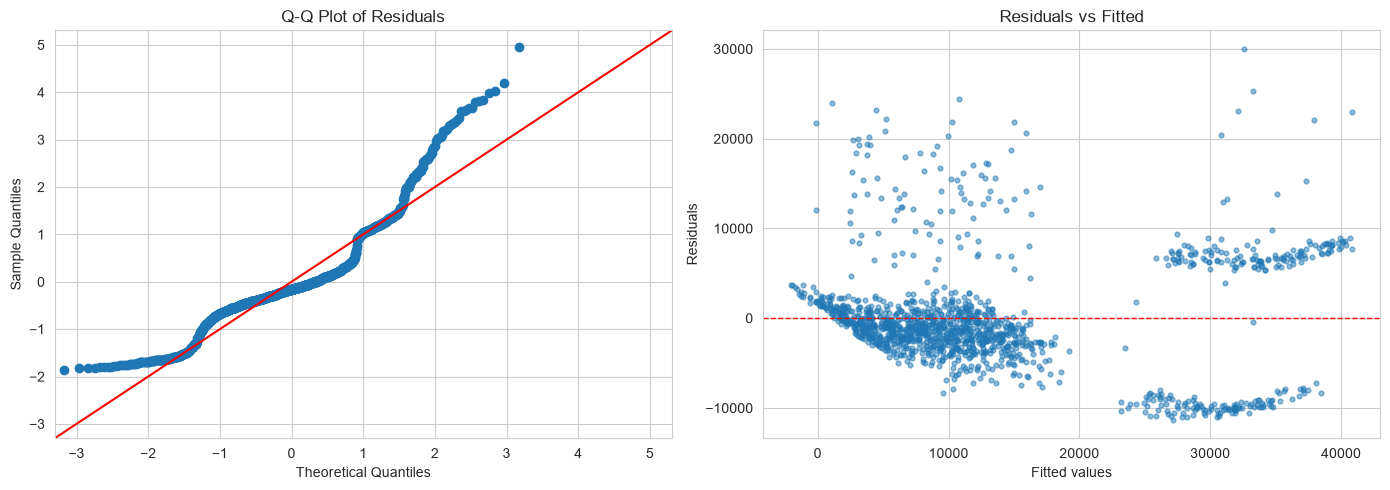

In [30]:
import matplotlib.pyplot as plt

residuals = model.resid
fitted    = model.fittedvalues

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Q-Q plot ---
sm.qqplot(residuals, line="45", ax=axes[0], fit=True)
axes[0].set_title("Q-Q Plot of Residuals")

# --- Residuals vs Fitted ---
axes[1].scatter(fitted, residuals, alpha=0.5, s=12)
axes[1].axhline(0, color="red", linestyle="--", linewidth=1)
axes[1].set_xlabel("Fitted values")
axes[1].set_ylabel("Residuals")
axes[1].set_title("Residuals vs Fitted")

plt.tight_layout()
plt.show()

In [33]:
from statsmodels.stats.stattools import omni_normtest, jarque_bera

residuals = model.resid

# Omnibus normality test
omni_stat, omni_p = omni_normtest(residuals)

# Jarque-Bera test
jb_stat, jb_p, jb_skew, jb_kurt = jarque_bera(residuals)

print("--- Normality of Residuals ---")
print(f"Omnibus     : stat = {omni_stat:.4f}, p = {omni_p:.4e}")
print(f"Jarque-Bera : stat = {jb_stat:.4f}, p = {jb_p:.4e}")
print(f"Skew        : {jb_skew:.4f}")
print(f"Kurtosis    : {jb_kurt:.4f}")

--- Normality of Residuals ---
Omnibus     : stat = 299.8161, p = 7.8661e-66
Jarque-Bera : stat = 716.5524, p = 2.5270e-156
Skew        : 1.2105
Kurtosis    : 5.6460


In [34]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Numeric / encoded predictors only (exclude const)
X_vif = X.drop(columns=["const"])

vif_data = pd.DataFrame({
    "feature": X_vif.columns,
    "VIF":     [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).round(3)

print("--- Variance Inflation Factor (VIF) ---")
print(vif_data)

print("\nRule of thumb:")
print("  VIF < 5   → no multicollinearity ")
print("  VIF 5-10  → moderate concern ")
print("  VIF > 10  → severe multicollinearity ")

--- Variance Inflation Factor (VIF) ---
            feature    VIF
0               age  1.017
1               bmi  1.107
2          children  1.004
3        smoker_yes  1.012
4          sex_male  1.009
5  region_northwest  1.518
6  region_southeast  1.652
7  region_southwest  1.529

Rule of thumb:
  VIF < 5   → no multicollinearity 
  VIF 5-10  → moderate concern 
  VIF > 10  → severe multicollinearity 


In [35]:
# Log-transform the target
df_model["log_charges"] = np.log(df_model["charges"])

# Refit OLS with log target (same predictors)
X_log = df_model.drop(columns=["charges", "log_charges"])
y_log = df_model["log_charges"]
X_log = sm.add_constant(X_log)

model_log = sm.OLS(y_log, X_log).fit()

print(model_log.summary())

                            OLS Regression Results                            
Dep. Variable:            log_charges   R-squared:                       0.768
Model:                            OLS   Adj. R-squared:                  0.766
Method:                 Least Squares   F-statistic:                     548.4
Date:                Sun, 13 Sep 2026   Prob (F-statistic):               0.00
Time:                        18:30:53   Log-Likelihood:                -807.62
No. Observations:                1337   AIC:                             1633.
Df Residuals:                    1328   BIC:                             1680.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                7.0315      0.072  

--- Log-model Residual Diagnostics ---
Omnibus     : stat = 462.9356, p = 2.9842e-101
Jarque-Bera : stat = 1667.6767, p = 0.0000e+00
Skew        : 1.6768   (raw model was 1.2105)
Kurtosis    : 7.3232   (raw model was 5.6460)
Durbin-Watson: 2.0475


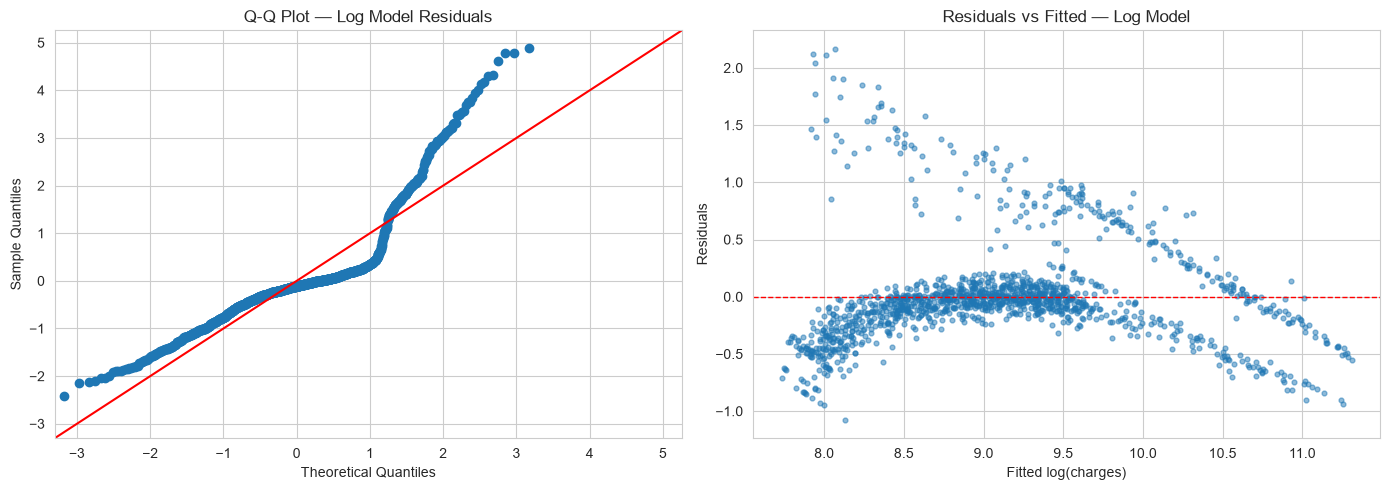

In [36]:
residuals_log = model_log.resid
fitted_log    = model_log.fittedvalues

# Diagnostics
from statsmodels.stats.stattools import omni_normtest, jarque_bera

omni_stat_l, omni_p_l = omni_normtest(residuals_log)
jb_stat_l, jb_p_l, jb_skew_l, jb_kurt_l = jarque_bera(residuals_log)

print("--- Log-model Residual Diagnostics ---")
print(f"Omnibus     : stat = {omni_stat_l:.4f}, p = {omni_p_l:.4e}")
print(f"Jarque-Bera : stat = {jb_stat_l:.4f}, p = {jb_p_l:.4e}")
print(f"Skew        : {jb_skew_l:.4f}   (raw model was 1.2105)")
print(f"Kurtosis    : {jb_kurt_l:.4f}   (raw model was 5.6460)")
print(f"Durbin-Watson: {sm.stats.durbin_watson(residuals_log):.4f}")

# Plot Q-Q + residual-vs-fitted side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sm.qqplot(residuals_log, line="45", ax=axes[0], fit=True)
axes[0].set_title("Q-Q Plot — Log Model Residuals")

axes[1].scatter(fitted_log, residuals_log, alpha=0.5, s=12)
axes[1].axhline(0, color="red", linestyle="--", linewidth=1)
axes[1].set_xlabel("Fitted log(charges)")
axes[1].set_ylabel("Residuals")
axes[1].set_title("Residuals vs Fitted — Log Model")

plt.tight_layout()
plt.show()

In [37]:
# Build interaction term: smoker × bmi
df_model["smoker_bmi"] = df_model["smoker_yes"] * df_model["bmi"]

# Define X, y
X_int = df_model.drop(columns=["charges", "log_charges"])
y_int = df_model["charges"]

X_int = sm.add_constant(X_int)
model_int = sm.OLS(y_int, X_int).fit()

print(model_int.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.841
Model:                            OLS   Adj. R-squared:                  0.840
Method:                 Least Squares   F-statistic:                     778.8
Date:                Sun, 13 Sep 2026   Prob (F-statistic):               0.00
Time:                        18:32:29   Log-Likelihood:                -13238.
No. Observations:                1337   AIC:                         2.650e+04
Df Residuals:                    1327   BIC:                         2.655e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -2222.3383    865.957  

--- Interaction Model — Residual Diagnostics ---
Omnibus      : stat = 720.6482, p = 3.2600e-157
Jarque-Bera  : stat = 4453.1925, p = 0.0000e+00
Skew         : 2.5275   (raw model 1.2105, log model 1.6768)
Kurtosis     : 10.3747   (raw model 5.6460, log model 7.3232)
Durbin-Watson: 2.0689


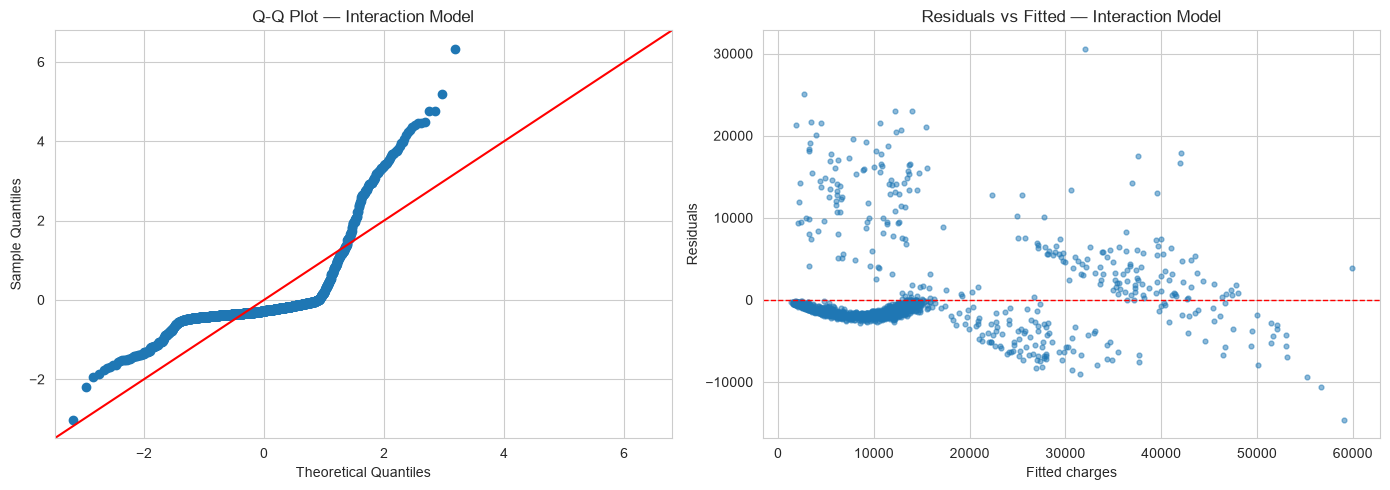

In [38]:
resid_i = model_int.resid
fitted_i = model_int.fittedvalues

omni_stat_i, omni_p_i = omni_normtest(resid_i)
jb_stat_i, jb_p_i, jb_skew_i, jb_kurt_i = jarque_bera(resid_i)

print("--- Interaction Model — Residual Diagnostics ---")
print(f"Omnibus      : stat = {omni_stat_i:.4f}, p = {omni_p_i:.4e}")
print(f"Jarque-Bera  : stat = {jb_stat_i:.4f}, p = {jb_p_i:.4e}")
print(f"Skew         : {jb_skew_i:.4f}   (raw model 1.2105, log model 1.6768)")
print(f"Kurtosis     : {jb_kurt_i:.4f}   (raw model 5.6460, log model 7.3232)")
print(f"Durbin-Watson: {sm.stats.durbin_watson(resid_i):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sm.qqplot(resid_i, line="45", ax=axes[0], fit=True)
axes[0].set_title("Q-Q Plot — Interaction Model")

axes[1].scatter(fitted_i, resid_i, alpha=0.5, s=12)
axes[1].axhline(0, color="red", linestyle="--", linewidth=1)
axes[1].set_xlabel("Fitted charges")
axes[1].set_ylabel("Residuals")
axes[1].set_title("Residuals vs Fitted — Interaction Model")

plt.tight_layout()
plt.show()

In [39]:
# Refit interaction model with HC3 robust standard errors
model_int_robust = sm.OLS(y_int, X_int).fit(cov_type="HC3")
print(model_int_robust.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.841
Model:                            OLS   Adj. R-squared:                  0.840
Method:                 Least Squares   F-statistic:                     606.5
Date:                Sun, 13 Sep 2026   Prob (F-statistic):               0.00
Time:                        18:34:17   Log-Likelihood:                -13238.
No. Observations:                1337   AIC:                         2.650e+04
Df Residuals:                    1327   BIC:                         2.655e+04
Df Model:                           9                                         
Covariance Type:                  HC3                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -2222.3383    780.738  